# Analiza zachowań konsumenckich oraz ocena efektywności sprzedaży w sektorze e-commerce
## 1. Cel projektu
Projekt koncentruje się na kompleksowej analizie danych pochodzących z platformy e-commerce w celu identyfikacji i zrozumienia kluczowych aspektów zachowań konsumenckich. W szczególności obejmuje analizę procesów zakupowych, charakterystyk demograficznych klientów oraz ocenę rentowności oferowanych produktów.

Głównym celem projektu jest przekształcenie surowych danych transakcyjnych w uporządkowane i użyteczne informacje, które umożliwią formułowanie trafnych wniosków strategicznych. Uzyskane rezultaty mają wspierać podejmowanie decyzji biznesowych oraz przyczyniać się do optymalizacji działań sprzedażowych i zwiększenia efektywności funkcjonowania platformy.

## 2. Pytania badawcze

* <b>Geografia sprzedaży: </b> Które rynki generują najwyższą średnią wartość zamówienia (AOV) w poszczególnych miesiącach?
* <b>Profil klienta:</b> Jak wiek i płeć użytkowników wpływają na preferencje zakupowe?
* <b>Logistyka i statusy:</b> Jaki procent zamówień jest zwracany lub anulowany i jak to wpływa na przychody?

## 3. O zbiorze danych
* <b>Źródło:</b> <a href="https://console.cloud.google.com/marketplace/product/bigquery-public-data/thelook-ecommerce?hl=en&project=single-ripsaw-431211-q0">Google BigQuery (Public Datasets)</a> 

* <b>Typ danych:</b> Syntetyczne dane e-commerce (wspójność logiczna).

* <b>Zakres:</b> 4 tabele relacyjne (Users, Products, Orders, Order Items).





In [121]:
# Import bibliotek
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sqlalchemy import create_engine,inspect
from dotenv import load_dotenv


In [122]:
# Wczytanie danych z pliku .env
load_dotenv()
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

In [123]:
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['axes.spines.top'] = False   
plt.rcParams['axes.spines.right'] = False  
plt.rcParams['font.size'] = 11
plt.rcParams['axes.facecolor'] = '#f9f9f9'

In [124]:
# Połączenie z bazą danych
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [125]:
# Import danych z plików CSV do bazy PostgreSQL
def import_data_to_postgres():
    files = {
        'products.csv': 'products',
        'orders.csv': 'orders',
        'order_items.csv': 'order_items',
        'users.csv': 'users'
    }
    
    inspector = inspect(engine)
    existing_tables = inspector.get_table_names()

    for file_name, table_name in files.items():
        try:
            
            if table_name in existing_tables:
                print(f"⏭️ Pominięto: Tabela '{table_name}' już istnieje w bazie.")
                continue

            print(f"⏳Wczytywanie {file_name}...")
            df = pd.read_csv(file_name)
            df.to_sql(table_name, engine, if_exists='fail', index=False) 
            print(f"✅Sukces: Tabela '{table_name}' została załadowana ({len(df)} wierszy).")

        except Exception as e:
            print(f"❌ Błąd przy pliku {file_name}: {e}")

import_data_to_postgres()

⏭️ Pominięto: Tabela 'products' już istnieje w bazie.
⏭️ Pominięto: Tabela 'orders' już istnieje w bazie.
⏭️ Pominięto: Tabela 'order_items' już istnieje w bazie.
⏭️ Pominięto: Tabela 'users' już istnieje w bazie.


In [126]:
import pandas as pd

def analyze_na(engine, table):
    query = f"SELECT * FROM {table}"
    with engine.connect() as connection:
        df = pd.read_sql_query(query, connection)
    return df

tables = ['users', 'orders', 'products', 'order_items']

all_nas = {t: analyze_na(engine, t).isna().sum() for t in tables}

summary_df = pd.DataFrame(all_nas).fillna(0).astype(int)

final_report = summary_df[summary_df.sum(axis=1) > 0]

print("--- RAPORT BRAKUJĄCYCH DANYCH (TYLKO KOLUMNY Z NA) ---")
print(final_report)


--- RAPORT BRAKUJĄCYCH DANYCH (TYLKO KOLUMNY Z NA) ---
              users  orders  products  order_items
brand             0       0        24            0
city           1016       0         0            0
delivered_at      0   82025         0       119116
name              0       0         2            0
returned_at       0  113249         0       164228
shipped_at        0   44173         0        64297


## Które rynki generują najwyższą średnią wartość zamówienia (AOV) w poszczególnych miesiącach?

In [127]:
def analyze_average_order_value(engine, month, year, min_age=0, max_age=100):
    query = f"""
    SELECT
        u.country AS kraj,
        COUNT(oi.id) AS ilosc_zamowien,
        ROUND(AVG(oi.sale_price)::numeric, 2) AS srednia_wartosc_koszyka
    FROM users AS u
    JOIN order_items AS oi ON u.id = oi.user_id
    JOIN orders AS o ON oi.order_id = o.order_id
    WHERE EXTRACT(MONTH FROM o.created_at) = {month}
      AND EXTRACT(YEAR FROM o.created_at) = {year}
      AND oi.returned_at IS NULL
      AND (u.age BETWEEN {min_age} AND {max_age})
    GROUP BY u.country
    ORDER BY srednia_wartosc_koszyka DESC;
    """

    df = pd.read_sql_query(query, engine)

    ax = sns.barplot(
        x='kraj',
        y='srednia_wartosc_koszyka',
        data=df,
        color='#2d6a4f'
    )

    for index, row in df.iterrows():
        value = row['srednia_wartosc_koszyka']
        count = row['ilosc_zamowien']

        # wartość średnia (góra słupka)
        ax.text(index,value + 0.3,f"{value}",ha='center',va='bottom',fontsize=10,fontweight='bold')

        # ilość zamówień (środek słupka)
        ax.text(index,value / 2,f"n={count}",ha='center',va='center',fontsize=9,color='white',fontweight='bold')

    plt.title(
        f"""Średnia wartość koszyka według krajów
        (Wiek: {min_age} - {max_age}) | {month}/{year}"""
    )
    plt.xlabel('Kraj')
    plt.ylabel('Średnia wartość koszyka')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

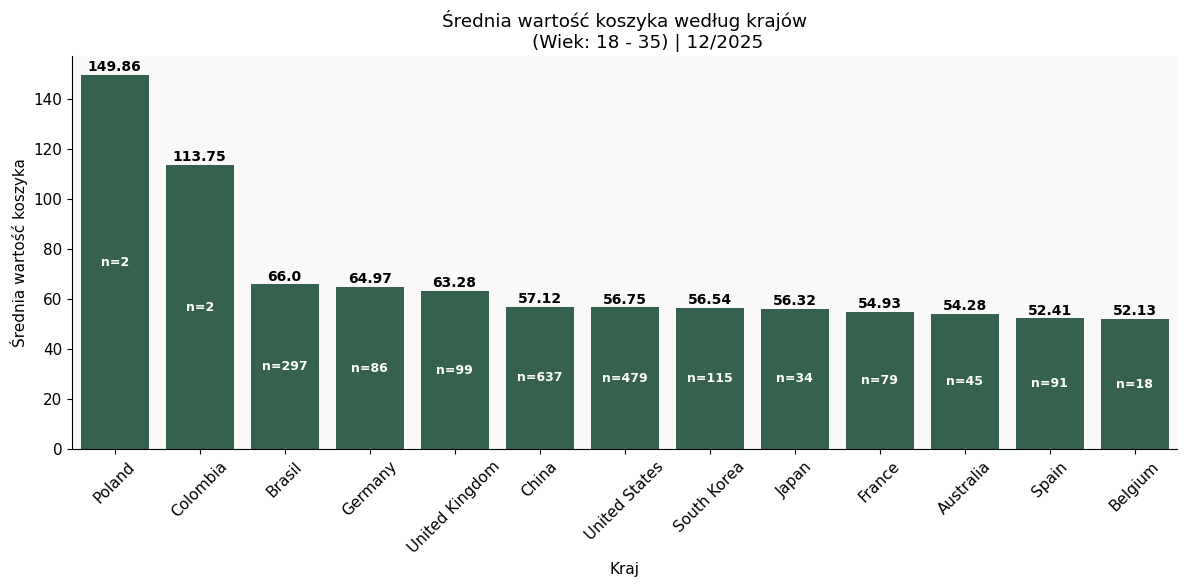

In [128]:
analyze_average_order_value(engine, month=12, year=2025, min_age=18, max_age=35)

Analiza średniej wartości koszyka (AOV) w przedziale wiekowym 18-35 – Grudzień 2025 

Mimo że na wykresie najwyższe wartości odnotowano dla Polski (149,86$) oraz Kolumbii (113,75$), wyniki te należy uznać za statystycznie nieistotne. W obu przypadkach liczba zamówień wynosi zaledwie 2, co oznacza, że pojedyncza transakcja o wysokiej wartości mogła całkowicie zaburzyć średnią, nie oddając rzeczywistego potencjału tych rynków.

Pierwszym krajem, w przypadku którego próba badawcza pozwala na wyciągnięcie rzetelnych wniosków, jest Brazylia. Przy znaczącej liczbie 297 zamówień, średnia wartość koszyka wyniosła tam 66.0$, co czyni ten rynek najbardziej dochodowym w zestawieniu z rynkami o ustabilizowanej pozycji.

Największą bazę transakcyjną odnotowano w Chinach n = 637 oraz USA n = 479 jednak tamtejszy średni koszyk jest o ok. 15% niższy niż w Brazylii i oscyluje wokół wartości 56-57.

Zasadne jest uruchomienie ukierunkowanych działań marketingowych w Polsce i Kolumbii. Celem byłoby zwiększenie liczby zamówień, co pozwoli sprawdzić, czy wysoka wartość koszyka utrzyma się przy większej skali sprzedaży.


## Jak wiek i płeć użytkowników wpływają na preferencje zakupowe?

In [129]:
def gender_order_analysis(engine, year, min_age=20, max_age=40):

    query = f"""SELECT
        CASE
            WHEN u.gender = 'M' THEN 'Mezczyzni'
            WHEN u.gender = 'F' THEN 'Kobiety'
            ELSE 'Inna plec'
        END AS Plec,
        ROUND(AVG(oi.total_value)::numeric, 2) AS Srednia_wartosc_zamowienia
    FROM users AS u
    JOIN orders AS o ON u.id = o.user_id
    JOIN (
        SELECT
            order_id,
            SUM(sale_price) AS total_value
        FROM order_items
        GROUP BY order_id
    ) AS oi ON o.order_id = oi.order_id
    WHERE u.age BETWEEN {min_age} AND {max_age}
    AND o.created_at BETWEEN '{year}-01-01' AND '{year}-12-31'
    GROUP BY u.gender
    ORDER BY Plec;"""

    df = pd.read_sql_query(query, engine)
    return df


In [130]:
min_age = 20
max_age = 60
gender_24 = gender_order_analysis(engine, year=2024, min_age=min_age, max_age=max_age)
gender_25 = gender_order_analysis(engine, year=2025, min_age=min_age, max_age=max_age)

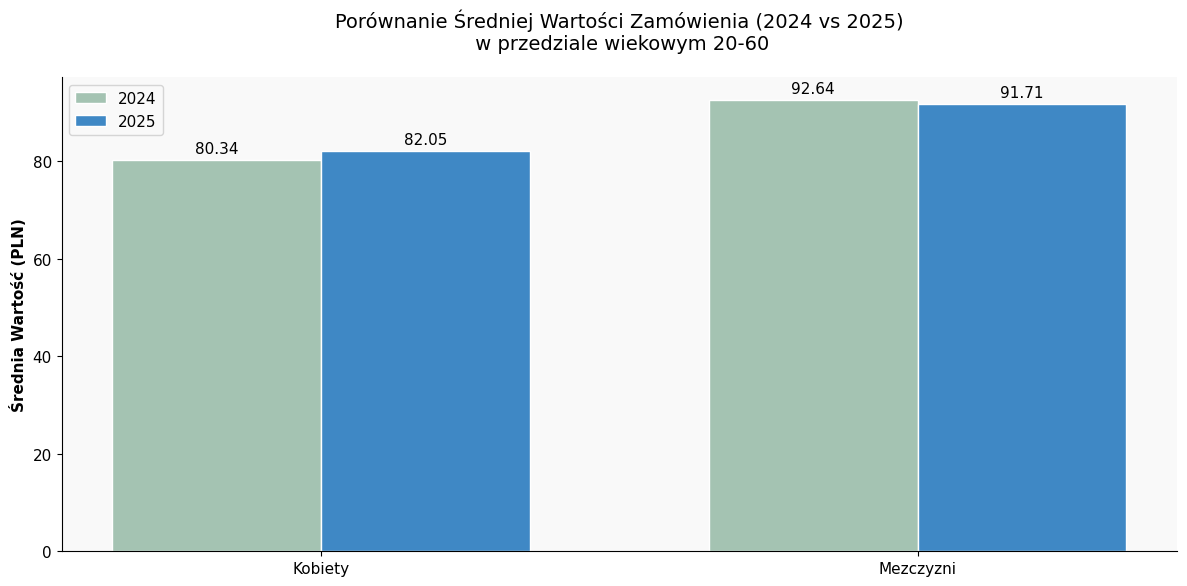

In [131]:
def painting_gender_comparison(data_1, data_2):
    labels = data_1['plec']
    val_2024 = data_1['srednia_wartosc_zamowienia']
    val_2025 = data_2['srednia_wartosc_zamowienia']

    x = np.arange(len(labels))  
    width = 0.35                


    fig, ax = plt.subplots()

    rects1 = ax.bar(x - width/2, val_2024, width, label='2024', color='#a4c3b2', edgecolor='white')
    rects2 = ax.bar(x + width/2, val_2025, width, label='2025', color='#3f88c5', edgecolor='white')

    ax.set_ylabel('Średnia Wartość (PLN)', fontweight='bold')
    ax.set_title(f'Porównanie Średniej Wartości Zamówienia (2024 vs 2025)\n w przedziale wiekowym {min_age}-{max_age}', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()

    ax.bar_label(rects1, padding=3, fmt='%.2f')
    ax.bar_label(rects2, padding=3, fmt='%.2f')

    plt.tight_layout()
    plt.show()

painting_gender_comparison(gender_24,gender_25)

Analiza średniej wartości koszyka (AOV) klientów w przedziale wiekowym 20–60 lat.

Dane wskazują na odwrotne trendy w grupach płci: podczas gdy średnia wartość zamówienia wśród kobiet wzrosła z 80,34$ w 2024 roku do 82,05$ w roku 2025, w grupie mężczyzn odnotowano lekki spadek – z poziomu 92,64$ do 91,71$.

Choć mężczyźni wciąż generują wyższą średnią wartość zamówienia, rok 2025 przyniósł wyraźne zmniejszenie luki zakupowej między płciami. Trend wzrostowy może sugerować lepsze dopasowanie oferty do ich potrzeb.


## Jaki procent zamówień jest zwracany i jak to wpływa na przychody?

In [132]:
def procentage_returned_items(engine):
    query = """
        SELECT 
        count(*) AS wszystkie_produkty,
        SUM(CASE WHEN status = 'Returned' THEN 1 ELSE 0 END) AS ilosc_zwrotow,
        ROUND(SUM(CASE WHEN status = 'Returned' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS procent_zwrotow
        FROM order_items;"""

    df = pd.read_sql_query(query, engine)

    fig, ax = plt.subplots(figsize=(8, 2))
    ax.axis('off') 
    
    total = f"{df['wszystkie_produkty'].iloc[0]:,}"
    perc = f"{df['procent_zwrotow'].iloc[0]}%"
    returns = f"{df['ilosc_zwrotow'].iloc[0]:,}"

    
    plt.text(0.1, 0.6, "Wszystkie produkty", fontsize=12, color='gray', ha='center')
    plt.text(0.1, 0.3, total, fontsize=24, fontweight='bold', ha='center')

    plt.text(0.5, 0.6, "Ilość zwrotów", fontsize=12, color='gray', ha='center')
    plt.text(0.5, 0.3, returns, fontsize=24, fontweight='bold', ha='center')

    plt.text(0.9, 0.6, "Wskaźnik zwrotów", fontsize=12, color='gray', ha='center')
    plt.text(0.9, 0.3, perc, fontsize=24, fontweight='bold', color='red', ha='center')
    
    plt.tight_layout()
    plt.show()

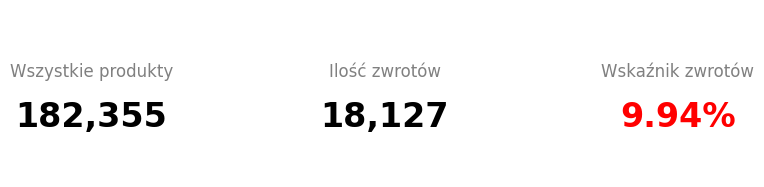

In [133]:
procentage_returned_items(engine)
    

In [134]:
def analyze_returned_items(engine,show_outliers = False):
    query = """ 
        SELECT p.category AS kategoria, oi.sale_price::numeric AS cena
        from order_items oi
        JOIN products p ON oi.product_id = p.id
        WHERE oi.status = 'Returned'; """
    
    df = pd.read_sql_query(query,engine)

    counts = df['kategoria'].value_counts()
    top_categories = counts.nlargest(15).index
    df_plot = df[df['kategoria'].isin(top_categories)].copy()
    
    label_map = {cat: f'{cat}(n={counts[cat]})' for cat in top_categories}
    df_plot['kategoria_label'] = df_plot['kategoria'].map(label_map)

    median_order = (df_plot.groupby('kategoria_label')['cena']
                    .median()
                    .sort_values(ascending=False)
                    .index
                    )
    
    plt.figure(figsize=(12,9))
    ax = sns.boxplot(
        x='cena', 
        y='kategoria_label', 
        data=df_plot, 
        order=median_order,
        hue='kategoria_label',
        legend=False,
        palette='Spectral',
        showfliers=show_outliers
    )
    if show_outliers:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(100)) 
    else:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(25)) 
    plt.title("Najdroższe wzroty z uwzględnieniem liczby produktów (Top 10)")
    plt.xlabel('Cena (USD)',fontsize=12)
    plt.ylabel('Kategoria (n= liczba zwrotów)',fontsize=12)
    plt.grid(axis='x',linestyle='--',alpha=0.6)
    plt.tight_layout()
    plt.show()

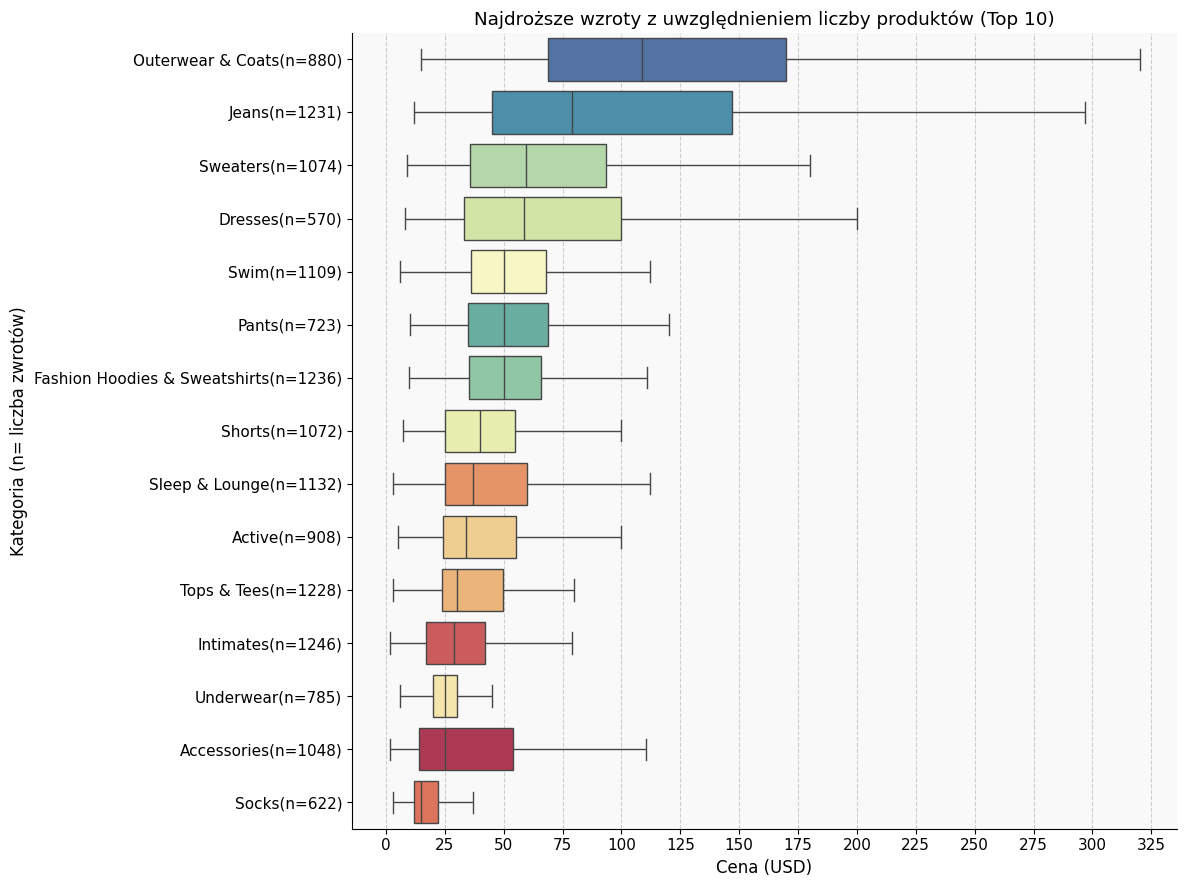

In [135]:
analyze_returned_items(engine)

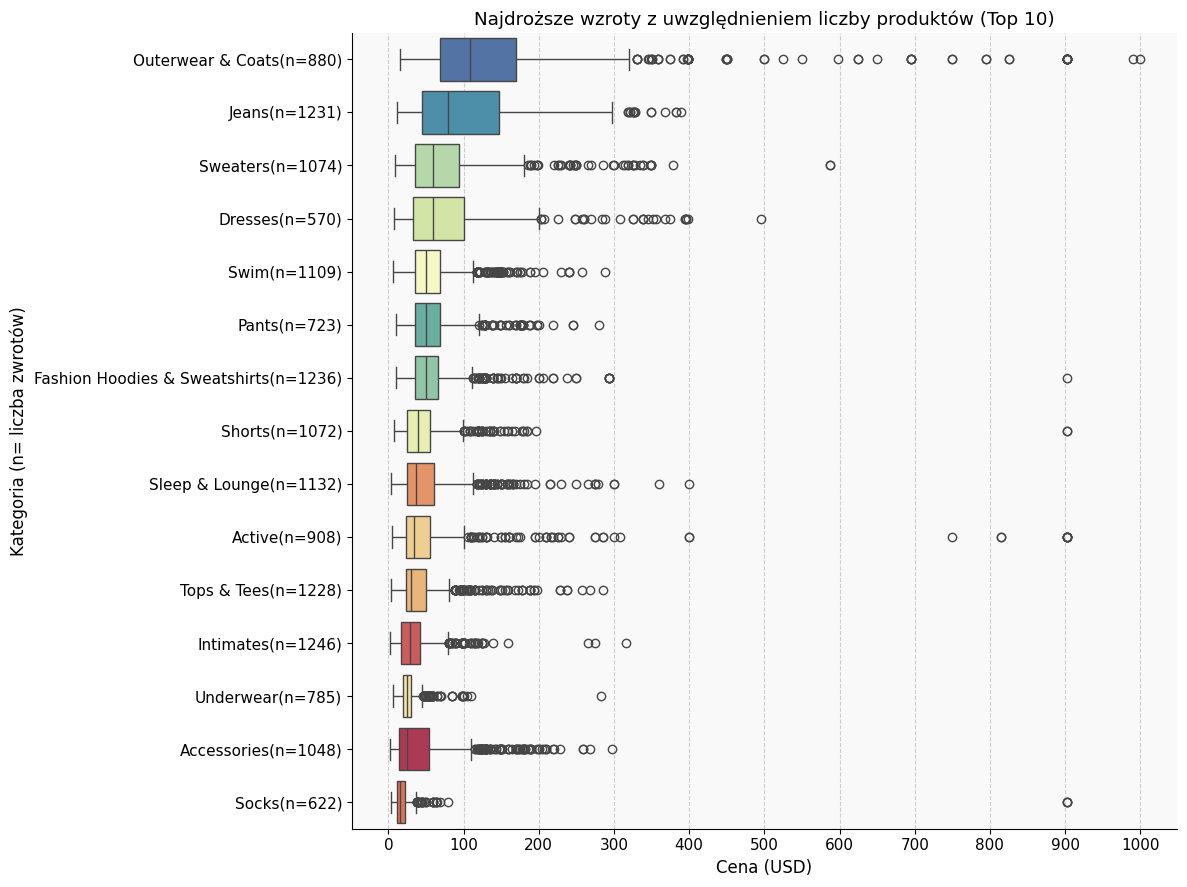

In [136]:
analyze_returned_items(engine, show_outliers=True)